In [ ]:
%pip install numpy==2.2.6 matplotlib==3.11.1

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
N = 50
d = 2

## Linear Data Regression

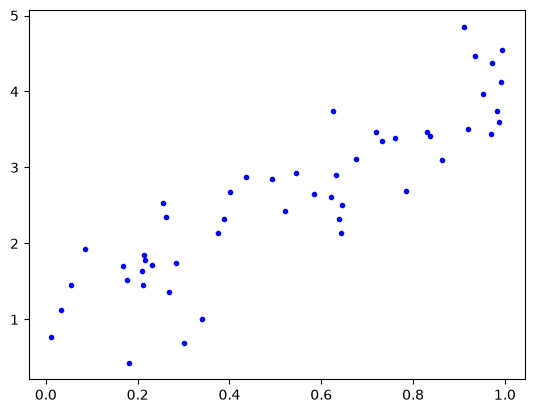

In [4]:
X = np.random.rand(N)
Y = 3 * X + 1 + 0.5*np.random.randn(N)
plt.plot(X, Y, '.b')

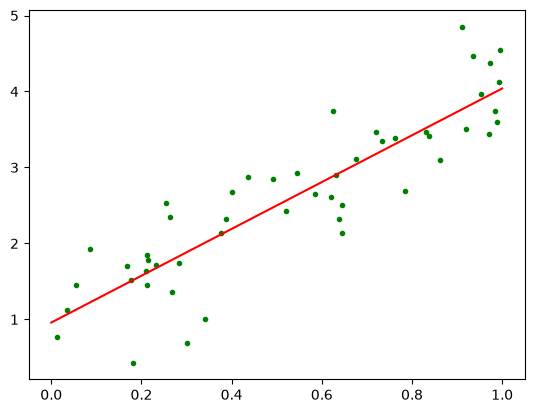

In [ ]:
X_ = np.vstack([X, np.ones(N)])
R = Y @ X_.T @ np.linalg.inv(X_ @ X_.T)
i = np.array([0, 1])
j = R[0] * i + R[1]
plt.plot(X, Y, '.g')
plt.plot(i, j, 'r')

## NONE Linear With Parabola

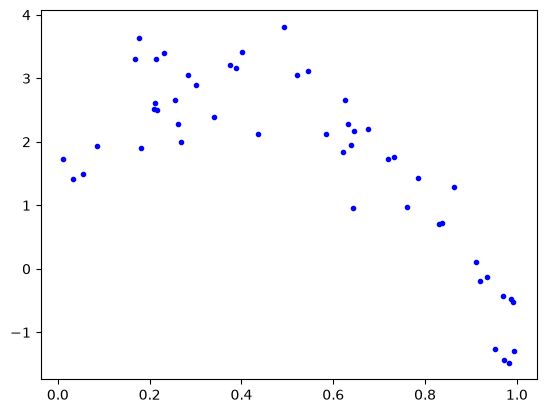

In [8]:
Y = 3 * np.sin(3 * X + 0.5) + 0.5*np.random.randn(N)
plt.plot(X, Y, '.b')

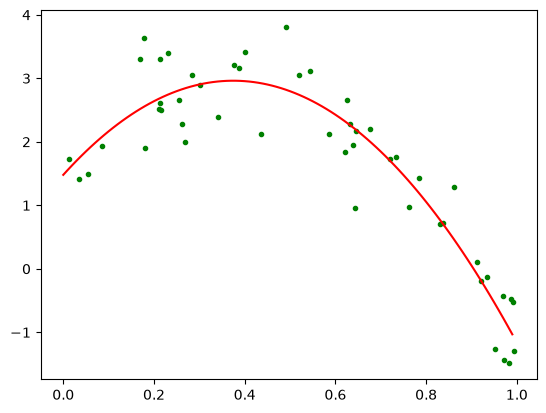

In [14]:
X_2 = np.vstack([X**2,X, np.ones(N)])
R_2 = Y @ X_2.T @ np.linalg.inv(X_2 @ X_2.T)
i = np.arange(0, 1, 0.01)
j = R_2[0] * i**2 + R_2[1] * i + R_2[2]
plt.plot(X, Y, '.g')
plt.plot(i, j, 'r')

## None Linear With More Power 

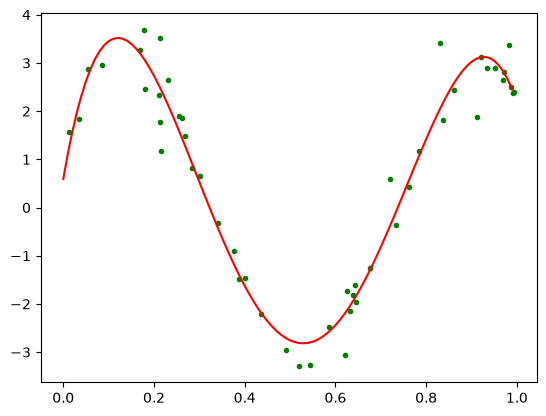

In [18]:
Y = 3 * np.sin(8 * X + 0.5) + 0.5*np.random.randn(N)
X_3 = np.vstack([X**4, X**3,X**2,X, np.ones(N)])
R_3 = Y @ X_3.T @ np.linalg.inv(X_3 @ X_3.T)
i = np.arange(0, 1, 0.01)
j = R_3[0] * i**4 + R_3[1] * i**3 + R_3[2] * i**2 + R_3[3] * i + R_3[4]
plt.plot(X, Y, '.g')
plt.plot(i, j, 'r')


## Loop For Add a Power

In [47]:
for M in range(4, 15):
  X_ = np.vstack((X, np.ones(len(X))))
  for n in range(2, M + 1):
    X_ = np.vstack((X**n, X_))

  R = Y @ X_.T @ np.linalg.inv(X_ @ X_.T)

  # i = np.arange(0, 1, 0.01)
  # j = 0
  # for n in range(M + 1):
  #   j += R[M - n] * i ** n
  # plt.plot(X, Y, '.r')
  # plt.plot(i, j, 'g')
  # plt.show()

  # error
  j = 0
  for n in range(M + 1):
    j += R[M - n] * X ** n
  e = np.mean(np.abs(Y - j)) # MAE
  print('Degree=', M, 'error=', e)

Degree= 4 error= 0.3428800274240161
Degree= 5 error= 0.3425979796200751
Degree= 6 error= 0.32438068407533094
Degree= 7 error= 0.3344153478520036
Degree= 8 error= 0.3311542974220042
Degree= 9 error= 0.32487699965030886
Degree= 10 error= 0.32494457833393203
Degree= 11 error= 0.34458459708612893
Degree= 12 error= 0.35147289954232236
Degree= 13 error= 0.3700367851756443
Degree= 14 error= 0.44289956449718704


## KNN Regressor

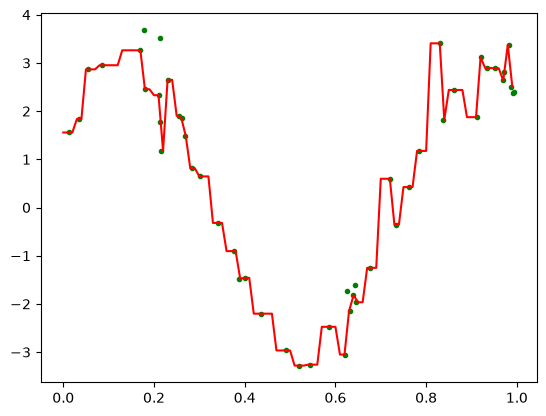

In [ ]:
k = 1
j = []
t = np.arange(0, 1, 0.01)

for i in t:
    d = np.abs(X - i)
    d_s = np.argsort(d)[:k]
    j.append(np.mean(Y[d_s]))

plt.plot(X, Y, '.g')
plt.plot(t, j, 'r-')
plt.show()
